In [2]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt

In [7]:
import os

path = r"C:\Users\kobby\Downloads"
os.chdir(path)

In [10]:
# Step 1: Replicating DVAR used in Questions a - d

In [8]:
# downloading e,p1 and p2 data

df = pd.read_csv(path + r'/financial econometrics.csv', parse_dates = ['Exchange Date'])
df.set_index('Exchange Date', inplace = True)

df.head()

C:\Users\kobby\AppData\Local\Temp\ipykernel_33380\478021420.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(path + r'/financial econometrics.csv', parse_dates = ['Exchange Date'])


,e,p1,p2
Exchange Date,,,
2001-01-31,0.4029,4.2843,5.1654
2001-02-28,0.3810,4.2870,5.1693
2001-03-31,0.3678,4.2904,5.1716
2001-04-30,0.3466,4.2962,5.1756
2001-05-31,0.3596,4.3038,5.1801


In [15]:
# Taking first differences

fd_df = df.diff().dropna()
fd_df.columns = ["de", "dp1", "dp2"]
fd_df.head()

,de,dp1,dp2
Exchange Date,,,
2001-02-28,-0.0219,0.0027,0.0039
2001-03-31,-0.0132,0.0034,0.0023
2001-04-30,-0.0212,0.0058,0.0040
2001-05-31,0.0130,0.0076,0.0045
2001-06-30,-0.0105,0.0020,0.0017


In [16]:
# Splitting training and forecast periods

train = fd_df.loc["2001-01-01":"2022-12-31"]
test = fd_df.loc["2023-01-31":"2025-12-31"]

print(len(train)) # should be 264 (is 263 because of taking first differences)
print(len(test)) # should be 36

263
36


In [17]:
# Estimating DVAR(2) using p = 2 from calculations in Questions a - d

model = VAR(train)
results = model.fit(2)

print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 10, May, 2026
Time:                     13:33:30
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -29.8471
Nobs:                     261.000    HQIC:                  -30.0186
Log likelihood:           2842.44    FPE:                8.18527e-14
AIC:                     -30.1339    Det(Omega_mle):     7.56050e-14
--------------------------------------------------------------------
Results for equation de
            coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------
const         -0.001799         0.001994           -0.902           0.367
L1.de          0.021709         0.064264            0.338           0.736
L1.dp1        -0.328648         0.459702           -0.715           0.475
L1.dp2         1.

C:\Users\kobby\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [18]:
# significant impact of lagged changes in US prices can be observed 
# on current UK price changes (check t-stats)

In [30]:
# Generating forecasts

lag_order = results.k_ar

forecast_input = train.values[-lag_order:]

forecast = results.forecast(
    y = forecast_input,
    steps = 36
)

forecast_df = pd.DataFrame(
    forecast,
    index = pd.date_range(
        start = "2023-01-01",
        periods = 36,
        freq = "MS"
    ),
    columns = train.columns
)

print(forecast_df.head())

                  de       dp1       dp2
2023-01-01 -0.002246 -0.002011 -0.000119
2023-02-01  0.005062  0.000470  0.001806
2023-03-01 -0.000130  0.001819  0.002664
2023-04-01  0.000492  0.002287  0.002693
2023-05-01 -0.000188  0.002427  0.002332


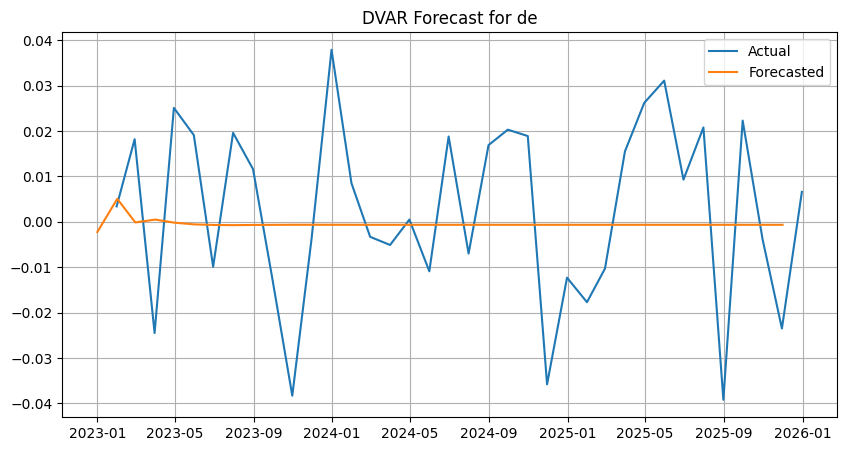

In [31]:
# Plotting Forecasts

plt.figure(figsize = (10,5))

plt.plot(
    test.index,
    test["de"],
    label = "Actual"
)
plt.plot(
    forecast_df.index,
    forecast_df["de"],
    label = "Forecasted"
)

plt.legend()
plt.grid()
plt.title("DVAR Forecast for de")
plt.show()

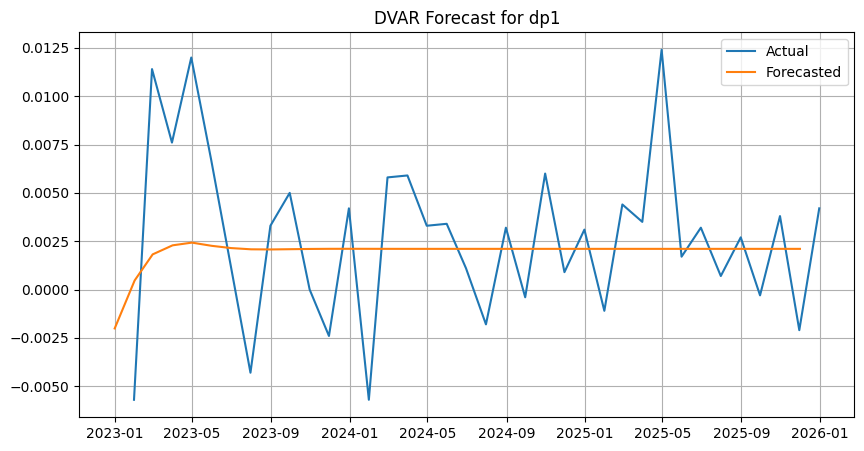

In [32]:
plt.figure(figsize = (10,5))

plt.plot(
    test.index,
    test["dp1"],
    label = "Actual"
)
plt.plot(
    forecast_df.index,
    forecast_df["dp1"],
    label = "Forecasted"
)

plt.legend()
plt.grid()
plt.title("DVAR Forecast for dp1")
plt.show()

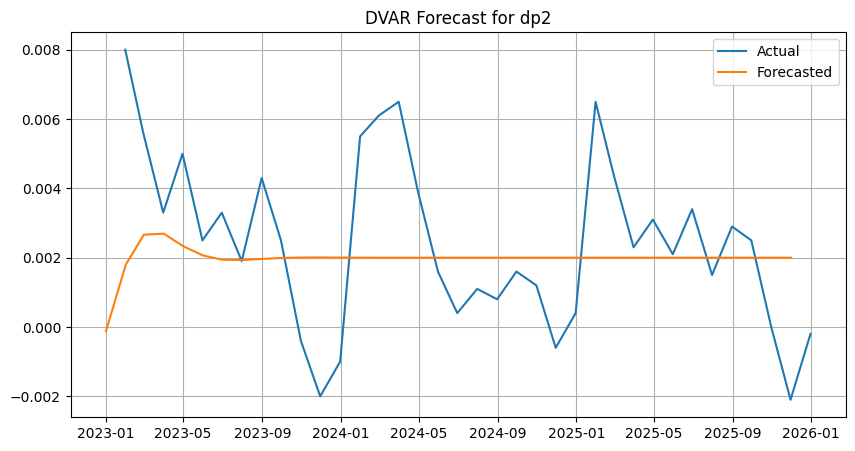

In [33]:
plt.figure(figsize = (10,5))

plt.plot(
    test.index,
    test["dp2"],
    label = "Actual"
)
plt.plot(
    forecast_df.index,
    forecast_df["dp2"],
    label = "Forecasted"
)

plt.legend()
plt.grid()
plt.title("DVAR Forecast for dp2")
plt.show()

In [42]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

In [43]:
# Step 2: Completing Task E - Univariate ARIMA Models

class UnivariateForecastingTask:
    """
    Building univariate ARIMA models for each variable and generating
    36 months forecasts.
    """

    def __init__(self, training_data):
        """ 
        Function stores training dataset, model statistics 
        (order (p, d, q) and aic), forecast results, and actual fitted 
        ARIMA objects (coefficients, residuals, diagnostics, forecasting methods)
        """
        self.training_data = training_data
        self.models = {}
        self.forecasts = {}
        self.fitted_models = {}

    def plot_acf_pacf(self, variable_name, variable_data, lags = 40):
        """
        Plots ACF and PACF to help determine ARIMA order
        """
        fig, axes = plt.subplots(1,2,figsize = (14,4))
        
        plot_acf(variable_data, lags = lags, ax = axes[0])
        axes[0].set_title(f"ACF - {variable_name}")
        
        plot_pacf(variable_data, lags = lags, ax = axes[1])
        axes[1].set_title(f"PACF - {variable_name}")

        plt.tight_layout()
        plt.show()

    def auto_select_arima(self, variable_name, variable_data, p_max = 3, q_max = 3):
        """
        Automatically selects ARIMA(p,0,q) order using AIC
        d = 0 because data is already differenced
        """
        best_aic = np.inf
        best_order = (0,0,0)
        results_list = []

        for p in range(p_max + 1):
            for q in range(q_max + 1):
                try:
                    model = ARIMA(variable_data, order = (p,0,q))
                    fitted = model.fit()

                    if fitted.aic < best_aic:
                        best_aic = fitted.aic
                        best_order = (p, 0, q)

                    results_list.append({
                    "Order": f"({p}, 0, {q})",
                    "AIC": fitted.aic,
                    "BIC": fitted.bic,
                    "RMSE": np.sqrt(fitted.mse)
                    })
                except:
                    pass
                    
        # Display results
        results_df = pd.DataFrame(results_list).sort_values("AIC")
        print(f"\nTop 5 Models by AIC:\n{results_df.head().to_string()}")
        print(f"\n Selected ARIMA{best_order}")
        print(f" AIC: {best_aic:.4f}")

        return best_order

    def fit_model(self, variable_name, variable_data, order = None):
        """
        Fit ARIMA model to variable
        IF order is none, auto select using AIC
        """
        if order is None:
            order = self.auto_select_arima(variable_name, variable_data)

        model = ARIMA(variable_data, order = order)
        fitted_model = model.fit()

        self.models[variable_name] = {
            "order": order,
            "aic": fitted_model.aic,
            "bic": fitted_model.bic,
            "rmse_insample": np.sqrt(fitted_model.mse)
        }
        self.fitted_models[variable_name] = fitted_model

        #Print summary
        print(f"\nARIMA Model Summary for {variable_name}:")
        print(f" Order: {order}")
        print(f" AIC: {fitted_model.aic:.4f}")
        print(f" In sample RMSE: {np.sqrt(fitted_model.mse):.6f}")

        return fitted_model

    def generate_forecasts(self, variable_name, fitted_model, steps = 36):
        """
        Generates out of sample forecasts for 36 months
        """
        forecast_result = fitted_model.get_forecast(steps = steps)
        forecast_values = forecast_result.predicted_mean
        confidence_intervals = forecast_result.conf_int(alpha = 0.05) # 95% confidence intervals

        self.forecasts[variable_name] = {
            "forecast": forecast_values,
            "ci_lower": confidence_intervals.iloc[:,0],
            "ci_upper":confidence_intervals.iloc[:,1]
        }
        print(f"\n Generated 36 month forecasts for {variable_name}")
        print(f" First 6 month forecasts:")
        print(forecast_values.head(6))

    def run_task_e(self):
        """
        Fits ARIMA models to de, dp1, dp2
        """
        print("Task E: Univariate ARIMA Models and Forecasting")

        for var_name in ["de", "dp1", "dp2"]:
            print(f"# {var_name.upper()}")

            variable_data = self.training_data[var_name]

            # Show ACF/PACF
            self.plot_acf_pacf(var_name, variable_data)

            # Auto select order
            order = self.auto_select_arima(
                var_name, 
                variable_data,
                p_max = 3,
                q_max = 3
            )

            # Fit model
            fitted_model = self.fit_model(
                var_name,
                variable_data, 
                order = order
            )

            # Generate forecasts
            self.generate_forecasts(
                var_name,
                fitted_model,
                steps = 36
            )

        return self.models, self.forecasts
        

    

Task E: Univariate ARIMA Models and Forecasting
# DE


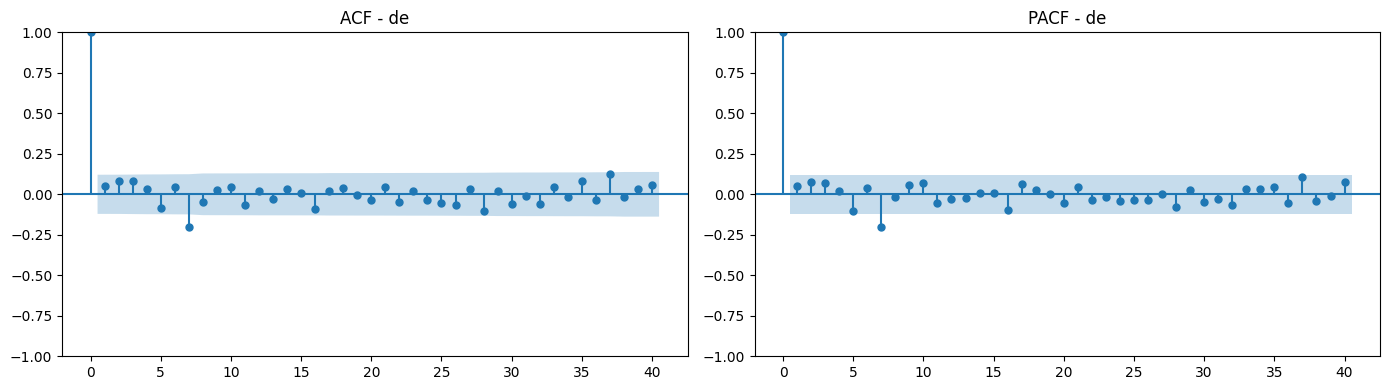


Top 5 Models by AIC:
        Order          AIC          BIC      RMSE
0   (0, 0, 0) -1183.236150 -1176.091842  0.025323
4   (1, 0, 0) -1181.959815 -1171.243353  0.025288
1   (0, 0, 1) -1181.852233 -1171.135771  0.025293
10  (2, 0, 2) -1181.638946 -1160.206022  0.025002
8   (2, 0, 0) -1181.626417 -1167.337801  0.025208

 Selected ARIMA(0, 0, 0)
 AIC: -1183.2361

ARIMA Model Summary for de:
 Order: (0, 0, 0)
 AIC: -1183.2361
 In sample RMSE: 0.025323

 Generated 36 month forecasts for de
 First 6 month forecasts:
2023-01-31   -0.000827
2023-02-28   -0.000827
2023-03-31   -0.000827
2023-04-30   -0.000827
2023-05-31   -0.000827
2023-06-30   -0.000827
Freq: ME, Name: predicted_mean, dtype: float64
# DP1


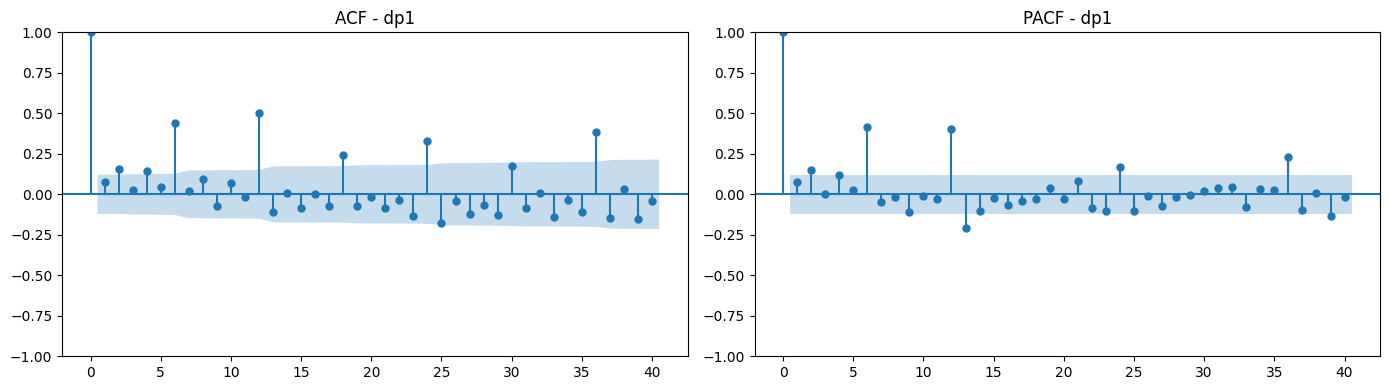


Top 5 Models by AIC:
        Order          AIC          BIC      RMSE
11  (2, 0, 3) -2185.602396 -2160.597318  0.003695
15  (3, 0, 3) -2171.400234 -2142.823002  0.003782
8   (2, 0, 0) -2169.690504 -2155.401888  0.003852
2   (0, 0, 2) -2168.207885 -2153.919269  0.003863
9   (2, 0, 1) -2167.716946 -2149.856175  0.003852

 Selected ARIMA(2, 0, 3)
 AIC: -2185.6024

ARIMA Model Summary for dp1:
 Order: (2, 0, 3)
 AIC: -2185.6024
 In sample RMSE: 0.003695

 Generated 36 month forecasts for dp1
 First 6 month forecasts:
2023-01-31    0.004520
2023-02-28    0.005934
2023-03-31    0.004428
2023-04-30    0.005474
2023-05-31    0.004225
2023-06-30    0.005076
Freq: ME, Name: predicted_mean, dtype: float64
# DP2


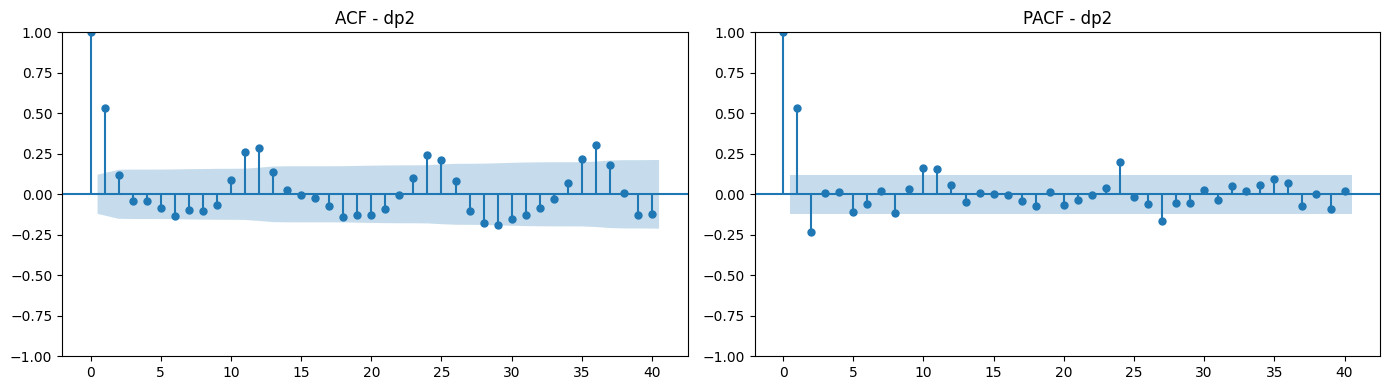


Top 5 Models by AIC:
        Order          AIC          BIC      RMSE
2   (0, 0, 2) -2259.716242 -2245.427626  0.003244
8   (2, 0, 0) -2259.150291 -2244.861674  0.003248
3   (0, 0, 3) -2258.302828 -2240.442057  0.003241
6   (1, 0, 2) -2258.258541 -2240.397771  0.003241
12  (3, 0, 0) -2257.152881 -2239.292111  0.003248

 Selected ARIMA(0, 0, 2)
 AIC: -2259.7162

ARIMA Model Summary for dp2:
 Order: (0, 0, 2)
 AIC: -2259.7162
 In sample RMSE: 0.003244

 Generated 36 month forecasts for dp2
 First 6 month forecasts:
2023-01-31   -0.000630
2023-02-28    0.001431
2023-03-31    0.002005
2023-04-30    0.002005
2023-05-31    0.002005
2023-06-30    0.002005
Freq: ME, Name: predicted_mean, dtype: float64


In [71]:
task_e = UnivariateForecastingTask(train)
univariate_models, univariate_forecasts = task_e.run_task_e()

In [72]:
# Create forecast DataFrame for Task F comparison
univariate_forecast_values = {}
for var_name in ['de', 'dp1', 'dp2']:
    univariate_forecast_values[var_name] = univariate_forecasts[var_name]['forecast'].values
    
univariate_forecasts_df = pd.DataFrame(
    univariate_forecast_values,
    index=test.index
    )

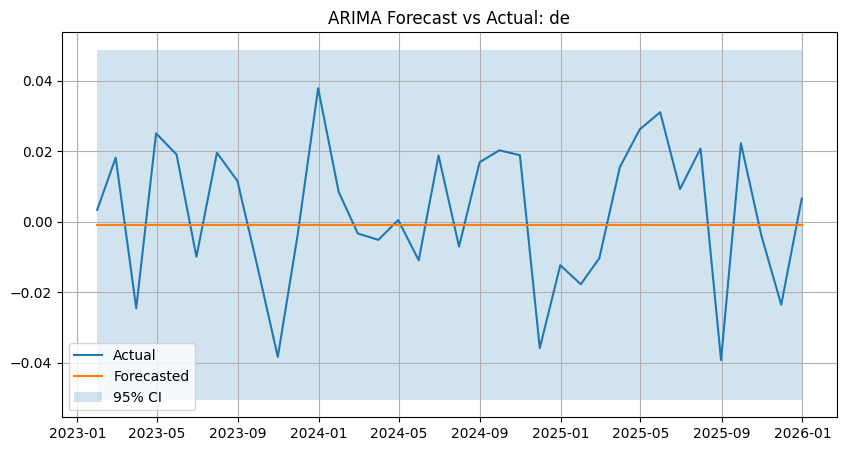

In [52]:
# Plotting ARIMA forecasts
forecast_de = task.forecasts["de"]["forecast"]
lower_de = task.forecasts["de"]["ci_lower"]
upper_de = task.forecasts["de"]["ci_upper"]
plt.figure(figsize = (10,5))

plt.plot(
    test.index,
    test["de"],
    label = "Actual"
)

plt.plot(
    forecast_de.index,
    forecast_de,
    label = "Forecasted"
)

plt.fill_between(
    forecast_de.index,
    lower_de,
    upper_de,
    alpha = 0.2,
    label = "95% CI"
)

plt.legend()
plt.grid()
plt.title("ARIMA Forecast vs Actual: de")
plt.show()

In [129]:
print(forecast_de.tail(15).mean())
print(np.std(forecast_de, ddof = 1))

-0.0008267491550292223
1.0995816948744301e-19


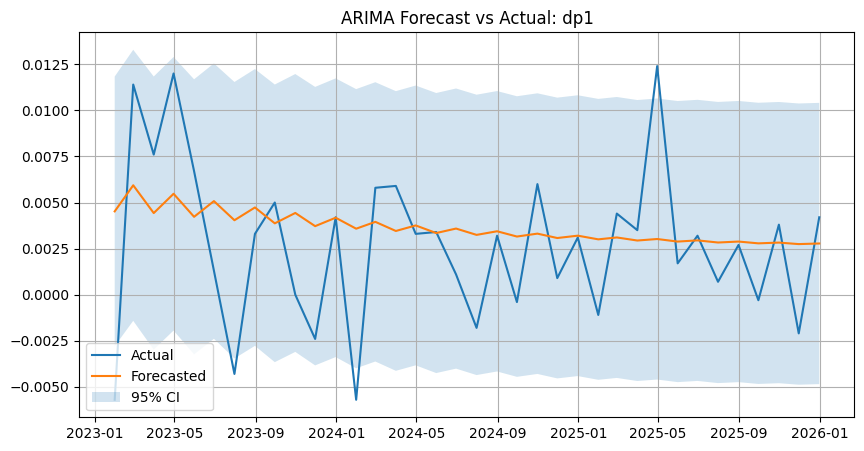

In [54]:
forecast_dp1 = task.forecasts["dp1"]["forecast"]
lower_dp1 = task.forecasts["dp1"]["ci_lower"]
upper_dp1 = task.forecasts["dp1"]["ci_upper"]
plt.figure(figsize = (10,5))

plt.plot(
    test.index,
    test["dp1"],
    label = "Actual"
)

plt.plot(
    forecast_dp1.index,
    forecast_dp1,
    label = "Forecasted"
)

plt.fill_between(
    forecast_dp1.index,
    lower_dp1,
    upper_dp1,
    alpha = 0.2,
    label = "95% CI"
)

plt.legend()
plt.grid()
plt.title("ARIMA Forecast vs Actual: dp1")
plt.show()

In [128]:
print(forecast_dp1.tail(15).mean())
print(np.std(forecast_dp1, ddof = 1))

0.002955440221970171
0.000807592769116128


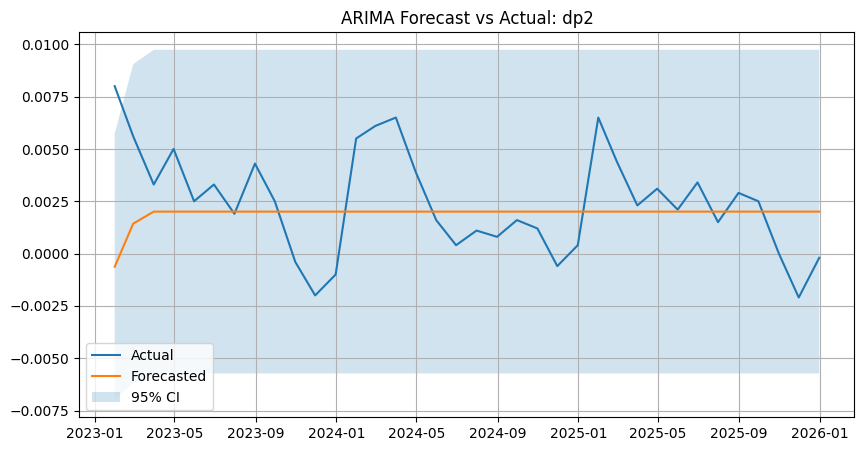

In [55]:
forecast_dp2 = task.forecasts["dp2"]["forecast"]
lower_dp2 = task.forecasts["dp2"]["ci_lower"]
upper_dp2 = task.forecasts["dp2"]["ci_upper"]
plt.figure(figsize = (10,5))

plt.plot(
    test.index,
    test["dp2"],
    label = "Actual"
)

plt.plot(
    forecast_dp2.index,
    forecast_dp2,
    label = "Forecasted"
)

plt.fill_between(
    forecast_dp2.index,
    lower_dp2,
    upper_dp2,
    alpha = 0.2,
    label = "95% CI"
)

plt.legend()
plt.grid()
plt.title("ARIMA Forecast vs Actual: dp2")
plt.show()

In [127]:
print(forecast_dp2.tail(15).mean())
print(np.std(forecast_dp2, ddof = 1))

0.0020047179530491076
0.00044665055007949854


In [57]:
print(task.fitted_models["dp1"].summary())

                               SARIMAX Results                                
Dep. Variable:                    dp1   No. Observations:                  263
Model:                 ARIMA(2, 0, 3)   Log Likelihood                1099.801
Date:                Sun, 10 May 2026   AIC                          -2185.602
Time:                        15:52:06   BIC                          -2160.597
Sample:                    02-28-2001   HQIC                         -2175.553
                         - 12-31-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0024      0.001      3.664      0.000       0.001       0.004
ar.L1          0.0308      0.193      0.159      0.873      -0.348       0.410
ar.L2          0.8510      0.152      5.609      0.0

In [85]:
# Step 3: Completing Task F - Comparison of DVAR and ARIMA Models
class ForecastComparisonTask:
    """
    Compare DVAR vs Univariate forecasts using accuracy metrics
    and Diebold–Mariano tests.
    """

    def __init__(self, actual_data, dvar_forecasts, univariate_forecasts):
        """
        Stores actual values (2023–2025), VAR forecasts, and ARIMA forecasts.
        """
        self.actual_data = actual_data
        self.dvar_forecasts = dvar_forecasts
        self.univariate_forecasts = univariate_forecasts
        self.accuracy_metrics = {}

    def calculate_mae(self, actual, forecast):
        """Mean Absolute Error"""
        return np.mean(np.abs(actual - forecast))

    def calculate_rmse(self, actual, forecast):
        """Root Mean Squared Error"""
        return np.sqrt(np.mean((actual - forecast) ** 2))

    def calculate_mape(self, actual, forecast):
        """Mean Absolute Percentage Error"""
        mask = actual != 0
        if mask.sum() > 0:
            return np.mean(np.abs((actual[mask] - forecast[mask]) / actual[mask])) * 100
        return np.nan

    def diebold_mariano_test(self, actual, forecast1, forecast2):
        """Diebold–Mariano test"""
        from scipy import stats

        e1 = (actual - forecast1) ** 2
        e2 = (actual - forecast2) ** 2
        d = e1 - e2

        d_bar = np.mean(d)
        var_d = np.var(d, ddof=1)
        n = len(d)

        dm_stat = d_bar / np.sqrt(var_d / n)
        p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

        interpretation = (
            "Significant difference (p < 0.05)"
            if abs(dm_stat) > 1.96
            else "No significant difference (p >= 0.05)"
        )

        return {
            "dm_statistic": dm_stat,
            "p_value": p_value,
            "interpretation": interpretation,
            "mean_loss_diff": d_bar,
            "var_loss_diff": var_d,
            "n_obs": n
        }

    def compare_by_horizon(self, variable_name, actual_var, dvar_var, univariate_var):
        """Compare accuracy by forecast horizon"""
        horizons = {
            "1–3 months": slice(0, 3),
            "4–12 months": slice(3, 12),
            "13–24 months": slice(12, 24),
            "25–36 months": slice(24, 36)
        }

        results = []

        for horizon_name, horizon_slice in horizons.items():
            a = actual_var.iloc[horizon_slice]
            d = dvar_var.iloc[horizon_slice]
            u = univariate_var.iloc[horizon_slice]

            results.append({
                "Horizon": horizon_name,
                "DVAR RMSE": self.calculate_rmse(a, d),
                "Univariate RMSE": self.calculate_rmse(a, u),
                "DVAR MAE": self.calculate_mae(a, d),
                "Univariate MAE": self.calculate_mae(a, u)
            })

        return pd.DataFrame(results)

    def plot_forecast_comparison(self, variable_name, actual_var, dvar_var, univariate_var):
        """Plot actual vs forecasts"""
        fig, ax = plt.subplots(figsize=(14, 6))

        months = np.arange(len(actual_var))

        ax.plot(months, actual_var.values, "o-", label="Actual", color="black")
        ax.plot(months, dvar_var.values, "s--", label="DVAR Forecast", color="blue")
        ax.plot(months, univariate_var.values, "^--", label="Univariate Forecast", color="red")

        ax.set_title(f"Forecast Comparison: {variable_name.upper()}")
        ax.set_xlabel("Months Ahead (2023–2025)")
        ax.set_ylabel("Value")
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def run_task_f(self):
        """Run full comparison and DM tests"""
        print("Task F: Forecast Comparison and Accuracy Testing")

        variables = [("de", "Δe"), ("dp1", "Δp1"), ("dp2", "Δp2")]

        all_metrics = []
        all_dm_tests = []

        for var_code, var_name in variables:
            print(f"\n# {var_name}")

            actual_var = self.actual_data[var_code]
            dvar_var = self.dvar_forecasts[var_code]
            univariate_var = self.univariate_forecasts[var_code]["forecast"]

            # Accuracy
            dvar_rmse = self.calculate_rmse(actual_var, dvar_var)
            univariate_rmse = self.calculate_rmse(actual_var, univariate_var)

            dvar_mae = self.calculate_mae(actual_var, dvar_var)
            univariate_mae = self.calculate_mae(actual_var, univariate_var)

            print("\nOverall Accuracy (36 months):")
            print(f"DVAR     RMSE={dvar_rmse:.6f}, MAE={dvar_mae:.6f}")
            print(f"UnivARIMA RMSE={univariate_rmse:.6f}, MAE={univariate_mae:.6f}")

            # Horizon comparison
            horizon_df = self.compare_by_horizon(var_name, actual_var, dvar_var, univariate_var)
            print("\nAccuracy by Horizon:")
            print(horizon_df.to_string(index=False))

            # DM test
            dm_result = self.diebold_mariano_test(actual_var, dvar_var, univariate_var)

            print("\nDiebold–Mariano Test:")
            print(f"DM Statistic: {dm_result['dm_statistic']:.4f}")
            print(f"p-value: {dm_result['p_value']:.4f}")
            print(f"Result: {dm_result['interpretation']}")

            # Store
            all_metrics.append({
                "Variable": var_name,
                "DVAR_RMSE": dvar_rmse,
                "Univariate_RMSE": univariate_rmse,
                "DVAR_MAE": dvar_mae,
                "Univariate_MAE": univariate_mae
            })

            all_dm_tests.append({
                "Variable": var_name,
                "DM_Statistic": dm_result["dm_statistic"],
                "p-value": dm_result["p_value"],
                "Significant": "Yes" if abs(dm_result["dm_statistic"]) > 1.96 else "No"
            })

        metrics_df = pd.DataFrame(all_metrics)
        dm_df = pd.DataFrame(all_dm_tests)

        print("\nSummary: Overall Accuracy")
        print(metrics_df.to_string(index=False))

        print("\nSummary: Diebold–Mariano Tests")
        print(dm_df.to_string(index=False))

        return metrics_df, dm_df


In [82]:
forecast_df.index = forecast_df.index + pd.offsets.MonthEnd(0)

In [84]:
task_f = ForecastComparisonTask(test, forecast_df, univariate_forecasts)
metrics_df, dm_df = task_f.run_task_f()

Task F: Forecast Comparison and Accuracy Testing

# Δe

Overall Accuracy (36 months):
DVAR     RMSE=0.019822, MAE=0.016835
UnivARIMA RMSE=0.020001, MAE=0.016995

Accuracy by Horizon:
     Horizon  DVAR RMSE  Univariate RMSE  DVAR MAE  Univariate MAE
  1–3 months   0.016313         0.017704  0.014384        0.015642
 4–12 months   0.022802         0.023026  0.019655        0.019836
13–24 months   0.016165         0.016182  0.013191        0.013192
25–36 months   0.021468         0.021500  0.018975        0.019004

Diebold–Mariano Test:
DM Statistic: -1.2388
p-value: 0.2154
Result: No significant difference (p >= 0.05)

# Δp1

Overall Accuracy (36 months):
DVAR     RMSE=0.004256, MAE=0.003281
UnivARIMA RMSE=0.004210, MAE=0.003136

Accuracy by Horizon:
     Horizon  DVAR RMSE  Univariate RMSE  DVAR MAE  Univariate MAE
  1–3 months   0.007450         0.006937  0.006800        0.006286
 4–12 months   0.004644         0.004630  0.003802        0.003806
13–24 months   0.003335         0.00355

In [86]:
# Step 4: Task G - Getting US monthly interest data for 3M, 2Y, 5Y and 10Y from January 2001 - February 2026

interest_rates_df = pd.read_csv(path + r"/interest rates.csv", parse_dates = ["Date"])
interest_rates_df.set_index("Date", inplace = True)

interest_rates_df.head()

,US3M,US2Y,US5Y,US10Y
Date,,,,
2026-02-27,3.6562,3.3749,3.5017,3.9375
2026-01-30,3.6537,3.5224,3.7881,4.2355
2025-12-31,3.6264,3.4730,3.7252,4.1670
2025-11-28,3.7956,3.4893,3.5964,4.0132
2025-10-31,3.8007,3.5736,3.6871,4.0775


In [89]:
interest_rates_df = interest_rates_df.iloc[::-1]
interest_rates_df.head()

,US3M,US2Y,US5Y,US10Y
Date,,,,
2001-01-31,4.994,4.572,4.768,5.114
2001-02-28,4.859,4.390,4.656,4.896
2001-03-30,4.286,4.180,4.557,4.917
2001-04-30,3.883,4.276,4.886,5.338
2001-05-31,3.616,4.188,4.914,5.381


In [90]:
# Creating interest rate spreads: 10Y - 3M, 5Y - 3M, 2Y - 3M

spreads = pd.DataFrame({
    "10Y_3M": interest_rates_df["US10Y"] - interest_rates_df["US3M"],
    "5Y_3M": interest_rates_df["US5Y"] - interest_rates_df["US3M"],
    "2Y_3M": interest_rates_df["US2Y"] - interest_rates_df["US3M"]
})

spreads.head()

,10Y_3M,5Y_3M,2Y_3M
Date,,,
2001-01-31,0.120,-0.226,-0.422
2001-02-28,0.037,-0.203,-0.469
2001-03-30,0.631,0.271,-0.106
2001-04-30,1.455,1.003,0.393
2001-05-31,1.765,1.298,0.572


In [91]:
print(f"\n Interest Rate Summary Statistics:")
print(interest_rates_df.describe().round(4))
print(f"\n Interest Rate Spreads Summary Statistics")
print(spreads.describe().round(4))


 Interest Rate Summary Statistics:
           US3M      US2Y      US5Y     US10Y
count  302.0000  302.0000  302.0000  302.0000
mean     1.7633    2.0868    2.6163    3.1857
std      1.8408    1.6010    1.3398    1.1959
min     -0.0203    0.1054    0.2044    0.5282
25%      0.0915    0.6013    1.5058    2.2036
50%      1.1197    1.6554    2.5142    3.2899
75%      3.3867    3.6069    3.7902    4.2053
max      5.4623    5.1498    5.0926    5.4120

 Interest Rate Spreads Summary Statistics
         10Y_3M     5Y_3M     2Y_3M
count  302.0000  302.0000  302.0000
mean     1.4223    0.8530    0.3235
std      1.3098    0.9758    0.5268
min     -1.7458   -1.6337   -1.1952
25%      0.3299    0.1568    0.0557
50%      1.5624    0.9278    0.3426
75%      2.4603    1.5428    0.6326
max      3.7891    3.0280    1.9340


In [92]:
spreads.to_csv("interest rate spreads.csv")

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

In [93]:
def run_adf_test(series, name, verbose = False):
    """
    Augmented Dickey - Fuller test
    H0: Series has unit root (non-stationary, I(1))
    H1: Series is stationary (I(0))

    Reject H0 if p-value < 0.05, Series is I(0)
    """
    series_clean = series.dropna()
    result = adfuller(series_clean, regression = "c", autolag = "AIC")

    test_result = {
    "Series": name,
    "Test": "ADF",
    "Statistic": result[0],
    "p-value": result[1],
    "Lags": result[2],
    "Obs": result[3],
    "Critical_1%": result[4]["1%"],
    "Critical_5%": result[4]["5%"],
    "Critical_10%": result[4]["10%"],
    "Order": "I(0)" if result[1] < 0.05 else "I(1)"
    }

    if verbose:
        print(f"\n ADF Test:")
        print(f" Statistic: {result[0]:.6f}")
        print(f" p-value: {result[1]:.6f}")
        print(f" Lags: {result[2]}")
        print(f" Critical (5%): {result[4]["5%"]:.4f}")
        print(f" Order: {test_result["Order"]}")

    return test_result

def run_kpss_test(series, name, verbose = False):
    """
    Run KPSS test ( reverses null hypothesis of ADF)
    H0: Series is stationary (I(0))
    H1: Series has unit root (non-stationary, I(1))

    Rejest H0 if p-value < 0.05, Series is I(1))
    Fail to reject H0 if p-value >= 0.05, Series is I(0)
    """
    series_clean = series.dropna()
    result = kpss(series_clean, regression = "c", nlags = "auto")

    test_result = {
    "Series": name,
    "Test": "KPSS",
    "Statistic": result[0],
    "p-value": result[1],
    "Lags": result[2],
    "Critical_1%": result[3]["1%"],
    "Critical_5%": result[3]["5%"],
    "Critical_10%": result[3]["10%"],
    "Order": "I(0)" if result[1] >= 0.05 else "I(1)"
    }

    if verbose:
        print(f"\n KPSS Test:")
        print(f" Statistic: {result[0]:.6f}")
        print(f" p-value: {result[1]:.6f}")
        print(f" Lags: {result[2]}")
        print(f" Critical (5%): {result[3]["5%"]:.4f}")
        print(f" Order: {test_result["Order"]}")

    return test_result
    

In [105]:
# Unit Root Tests on Individual Rates

individual_adf_results = []
individual_kpss_results = []

for rate_name in interest_rates_df.columns:
    print(f"\n{rate_name.upper()}")

    series = interest_rates_df[rate_name]

    # ADF Test
    adf_result = run_adf_test(series, rate_name, verbose = True)
    individual_adf_results.append(adf_result)

    # KPSS Test
    kpss_result = run_kpss_test(series, rate_name, verbose = True)
    individual_kpss_results.append(kpss_result)

    # Agreement Check
    adf_order = adf_result["Order"]
    kpss_order = kpss_result["Order"]
    agreement = "Yes" if adf_order == kpss_order else "No (Mixed)"
    final_order = adf_order if adf_order == kpss_order else "Mixed - Assume I(1)"

    print(f"\n Agreement between tests: {agreement}")
    print(f" Final Conclusion: {final_order}")

# Combine individual rate results
individual_adf_df = pd.DataFrame(individual_adf_results)
individual_kpss_df = pd.DataFrame(individual_kpss_results)

# Summary table for individual rates
print("Summary: Individual Rates Unit Root Tests")

summary_individual = []
for rate_name in interest_rates_df.columns:
    adf_row = individual_adf_df[individual_adf_df['Series'] == rate_name].iloc[0]
    kpss_row = individual_kpss_df[individual_kpss_df['Series'] == rate_name].iloc[0]

    agreement = "Yes" if adf_row['Order'] == kpss_row['Order'] else "No"
    final = adf_row['Order'] if agreement == "Yes" else "Mixed"

    summary_individual.append({
    'Rate': rate_name,
    'ADF_Stat': adf_row['Statistic'],
    'ADF_p-value': adf_row['p-value'],
    'ADF_Order': adf_row['Order'],
    'KPSS_Stat': kpss_row['Statistic'],
    'KPSS_p-value': kpss_row['p-value'],
    'KPSS_Order': kpss_row['Order'],
    'Agreement': agreement,
    'Final_Order': final
    })

individual_summary_df = pd.DataFrame(summary_individual)
print("\n" + individual_summary_df.to_string(index = False))


US3M

 ADF Test:
 Statistic: -2.434408
 p-value: 0.132260
 Lags: 5
 Critical (5%): -2.8714
 Order: I(1)

 KPSS Test:
 Statistic: 0.380695
 p-value: 0.085476
 Lags: 10
 Critical (5%): 0.4630
 Order: I(0)

 Agreement between tests: No (Mixed)
 Final Conclusion: Mixed - Assume I(1)

US2Y

 ADF Test:
 Statistic: -3.235467
 p-value: 0.018021
 Lags: 15
 Critical (5%): -2.8717
 Order: I(0)

 KPSS Test:
 Statistic: 0.407671
 p-value: 0.073849
 Lags: 10
 Critical (5%): 0.4630
 Order: I(0)

 Agreement between tests: Yes
 Final Conclusion: I(0)

US5Y

 ADF Test:
 Statistic: -2.096036
 p-value: 0.246112
 Lags: 0
 Critical (5%): -2.8712
 Order: I(1)

 KPSS Test:
 Statistic: 0.653404
 p-value: 0.017781
 Lags: 10
 Critical (5%): 0.4630
 Order: I(1)

 Agreement between tests: Yes
 Final Conclusion: I(1)

US10Y

 ADF Test:
 Statistic: -2.199775
 p-value: 0.206327
 Lags: 0
 Critical (5%): -2.8712
 Order: I(1)

 KPSS Test:
 Statistic: 1.064268
 p-value: 0.010000
 Lags: 10
 Critical (5%): 0.4630
 Order: 

In [97]:
individual_summary_df.to_csv('individual_rates_summary.csv', index = False)

In [102]:
# Unit Root Test on Spreads

spread_adf_results = []
spread_kpss_results = []

for spread_name in spreads.columns:
    print(f"\n{spread_name.upper()}")

    series = spreads[spread_name]

    # ADF Test
    adf_result = run_adf_test(series, spread_name, verbose = True)
    spread_adf_results.append(adf_result)

    # KPPS Test
    kpss_result = run_kpss_test(series, spread_name, verbose = True)
    spread_kpss_results.append(kpss_result)

    # Agreement check and EH implication
    adf_order = adf_result['Order']
    kpss_order = kpss_result['Order']
    agreement = "Yes" if adf_order == kpss_order else "Mixed"

    eh_support = "Yes" if final_order == 'I(0)' else ("No" if final_order == 'I(1)' else 'Unclear')

    print(f"\n Agreement between tests: {agreement}")
    print(f" Final conclusion: {final_order}")
    print(f" EH Support: {eh_support}")


#Combine spread results
spread_adf_df = pd.DataFrame(spread_adf_results)
spread_kpss_df = pd.DataFrame(spread_kpss_results)

# Summary table for spreads
print("Summary: Spreads Unit Root Tests")

summary_spreads = []
for spread_name in spreads.columns:
    adf_row = spread_adf_df[spread_adf_df['Series'] == spread_name].iloc[0]
    kpss_row = spread_kpss_df[spread_kpss_df['Series'] == spread_name].iloc[0]

    agreement  ="Yes" if adf_row['Order'] == kpss_row['Order'] else 'No'
    final = adf_row['Order'] if agreement == 'Yes' else 'Mixed'

    eh_support = 'Yes' if final == 'I(0)' else ('No' if final == 'I(1)' else 'Unclear')

    summary_spreads.append({
    'Spread': spread_name,
    'ADF_Statistic': adf_row['Statistic'],
    'ADF_p-value': adf_row['p-value'],
    'ADF_Order': adf_row['Order'],
    'KPSS_Statistic': kpss_row['Statistic'],
    'KPSS_p-value': kpss_row['p-value'],
    'KPSS_Order': kpss_row['Order'],
    'Agreement': agreement,
    'Final_Order': final,
    'EH_Support': eh_support
    })

spread_summary_df = pd.DataFrame(summary_spreads)
print('\n' + spread_summary_df.to_string(index = False))


10Y_3M

 ADF Test:
 Statistic: -1.902324
 p-value: 0.330969
 Lags: 3
 Critical (5%): -2.8713
 Order: I(1)

 KPSS Test:
 Statistic: 1.067154
 p-value: 0.010000
 Lags: 10
 Critical (5%): 0.4630
 Order: I(1)

 Agreement between tests: Yes
 Final conclusion: I(1)
 EH Support: No

5Y_3M

 ADF Test:
 Statistic: -2.568741
 p-value: 0.099632
 Lags: 0
 Critical (5%): -2.8712
 Order: I(1)

 KPSS Test:
 Statistic: 1.039547
 p-value: 0.010000
 Lags: 10
 Critical (5%): 0.4630
 Order: I(1)

 Agreement between tests: Yes
 Final conclusion: I(1)
 EH Support: No

2Y_3M

 ADF Test:
 Statistic: -3.816397
 p-value: 0.002744
 Lags: 0
 Critical (5%): -2.8712
 Order: I(0)

 KPSS Test:
 Statistic: 0.779904
 p-value: 0.010000
 Lags: 10
 Critical (5%): 0.4630
 Order: I(1)

 Agreement between tests: Mixed
 Final conclusion: I(1)
 EH Support: No
Summary: Spreads Unit Root Tests

Spread  ADF_Statistic  ADF_p-value ADF_Order  KPSS_Statistic  KPSS_p-value KPSS_Order Agreement Final_Order EH_Support
10Y_3M      -1.9

In [103]:
spread_summary_df.to_csv('spreads_summary.csv', index = False)

In [108]:
print("COMPREHENSIVE ANALYSIS & INTERPRETATION")

# Create unified summary
print("INDIVIDUAL RATES: Integration Order")
 
print(f"\n{'Rate':<15} {'ADF Order':<15} {'KPSS Order':<15} {'Final Order':<15}")
for _, row in individual_summary_df.iterrows():
    print(f"{row['Rate']:<15} {row['ADF_Order']:<15} {row['KPSS_Order']:<15} {row['Final_Order']:<15}")
 
print("SPREADS: Integration Order & EH Support")

print(f"\n{'Spread':<15} {'ADF Order':<15} {'KPSS Order':<15} {'Final Order':<15} {'EH Support':<15}")
for _, row in spread_summary_df.iterrows():
    print(f"{row['Spread']:<15} {row['ADF_Order']:<15} {row['KPSS_Order']:<15} {row['Final_Order']:<15} {row['EH_Support']:<15}")

COMPREHENSIVE ANALYSIS & INTERPRETATION
INDIVIDUAL RATES: Integration Order

Rate            ADF Order       KPSS Order      Final Order    
US3M            I(1)            I(0)            Mixed          
US2Y            I(0)            I(0)            I(0)           
US5Y            I(1)            I(1)            I(1)           
US10Y           I(1)            I(1)            I(1)           
SPREADS: Integration Order & EH Support

Spread          ADF Order       KPSS Order      Final Order     EH Support     
10Y_3M          I(1)            I(1)            I(1)            No             
5Y_3M           I(1)            I(1)            I(1)            No             
2Y_3M           I(0)            I(1)            Mixed           Unclear        


In [109]:
print("EXPECTATIONS HYPOTHESIS INTERPRETATION")

# Count stationary spreads
stationary_spreads = (spread_summary_df['Final_Order'] == 'I(0)').sum()
total_spreads = len(spread_summary_df)
 
print(f"\nStationary spreads (I(0)): {stationary_spreads}/{total_spreads}")
 
if stationary_spreads == total_spreads:
    eh_conclusion = "Strong Support for the Expectations Hypothesis"
    eh_reasoning = """
    All spreads are stationary (I(0)):
    - Long and short rates move together in the long run
    - The yield curve is anchored to an equilibrium
    - Spreads mean-revert → no arbitrage opportunities
    - Rates are COINTEGRATED with coefficient = 1
    
    IMPLICATION FOR TASK I (Johansen Test):
    → Expect 1 cointegrating vector (the spread relationship)
    → Cointegrating vector will be close to (1, -1)
    
    IMPLICATION FOR TASK J (Granger Causality):
    → Spreads should Granger-cause short rate changes
    → High spreads predict rising short rates
    → Low spreads predict falling short rates
    """
elif stationary_spreads > total_spreads / 2:
    eh_conclusion = "Moderate Support for the Expectations Hypothesis"
    eh_reasoning = """
    Most spreads are stationary (I(0)):
    - Several rate pairs are cointegrated
    - The term structure has some equilibrium anchoring
    - Some spreads exhibit mean reversion
    
    IMPLICATION FOR TASK I (Johansen Test):
    → Expect 1 or possibly 2 cointegrating vectors
    → Some but not all rate relationships are stable
    
    IMPLICATION FOR TASK J (Granger Causality):
    → Selective Granger causality from spreads to rates
    → Some spreads predict rate changes, others don't
    """
else:
    eh_conclusion = "Weak Support for the Expectations Hypothesis"
    eh_reasoning = """
    Few spreads are stationary (I(1)):
    - Long and short rates can drift apart indefinitely
    - The term structure lacks clear equilibrium anchoring
    - Spreads behave like random walks
    - Possible market inefficiency or regime changes
    
    IMPLICATION FOR TASK I (Johansen Test):
    → Expect 0 cointegrating vectors
    → Rates are not cointegrated (at least not with simple coefficients)
    
    IMPLICATION FOR TASK J (Granger Causality):
    → Limited or no Granger causality from spreads to rates
    → Spreads don't predict future rate movements
    """
 
print(f"\nConclusion: {eh_conclusion}")
print(eh_reasoning)

EXPECTATIONS HYPOTHESIS INTERPRETATION

Stationary spreads (I(0)): 0/3

Conclusion: Weak Support for the Expectations Hypothesis

    Few spreads are stationary (I(1)):
    - Long and short rates can drift apart indefinitely
    - The term structure lacks clear equilibrium anchoring
    - Spreads behave like random walks
    - Possible market inefficiency or regime changes

    IMPLICATION FOR TASK I (Johansen Test):
    → Expect 0 cointegrating vectors
    → Rates are not cointegrated (at least not with simple coefficients)

    IMPLICATION FOR TASK J (Granger Causality):
    → Limited or no Granger causality from spreads to rates
    → Spreads don't predict future rate movements
    


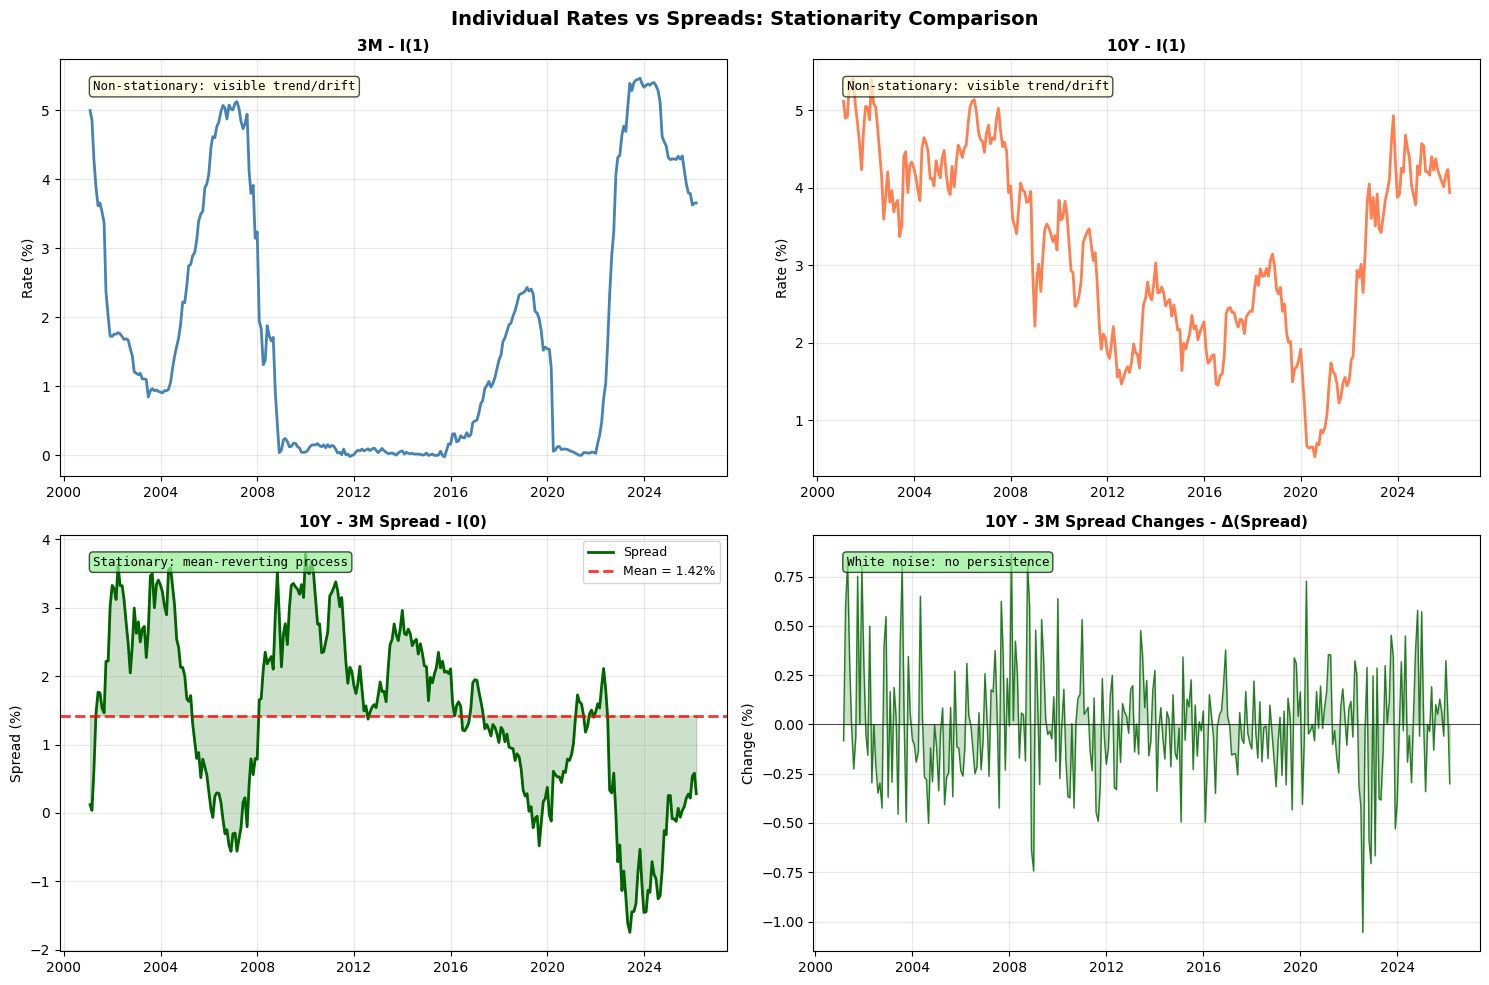

In [110]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Individual Rates vs Spreads: Stationarity Comparison', 
             fontsize=14, fontweight='bold')
 
# Plot 1: 3M Rate (I(1))
ax = axes[0, 0]
ax.plot(interest_rates_df.index, interest_rates_df['US3M'], linewidth=2, color='steelblue')
ax.set_title('3M - I(1)', fontweight='bold', fontsize=11)
ax.set_ylabel('Rate (%)')
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, 'Non-stationary: visible trend/drift',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7),
        fontsize=9, family='monospace')
 
# Plot 2: 10Y Rate (I(1))
ax = axes[0, 1]
ax.plot(interest_rates_df.index, interest_rates_df['US10Y'], linewidth=2, color='coral')
ax.set_title('10Y - I(1)', fontweight='bold', fontsize=11)
ax.set_ylabel('Rate (%)')
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, 'Non-stationary: visible trend/drift',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7),
        fontsize=9, family='monospace')
 
# Plot 3: 10Y-3M Spread (expected I(0))
ax = axes[1, 0]
spread_10y3m = spreads['10Y_3M']
ax.plot(spreads.index, spread_10y3m, linewidth=2, color='darkgreen', label='Spread')
ax.axhline(y=spread_10y3m.mean(), color='red', linestyle='--', linewidth=2, 
           alpha=0.8, label=f"Mean = {spread_10y3m.mean():.2f}%")
ax.fill_between(spreads.index, spread_10y3m, spread_10y3m.mean(), 
                 alpha=0.2, color='darkgreen')
ax.set_title('10Y - 3M Spread - I(1)', fontweight='bold', fontsize=11)
ax.set_ylabel('Spread (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, 'Stationary: mean-reverting process',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7),
        fontsize=9, family='monospace')
 
# Plot 4: Spread changes (strongly I(0))
ax = axes[1, 1]
spread_changes = spread_10y3m.diff()
ax.plot(spreads.index, spread_changes, linewidth=1, color='darkgreen', alpha=0.8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.fill_between(spreads.index, spread_changes, alpha=0.2, color='darkgreen')
ax.set_title('10Y - 3M Spread Changes - Δ(Spread)', fontweight='bold', fontsize=11)
ax.set_ylabel('Change (%)')
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, 'White noise: no persistence',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7),
        fontsize=9, family='monospace')
 
plt.tight_layout()
plt.show()


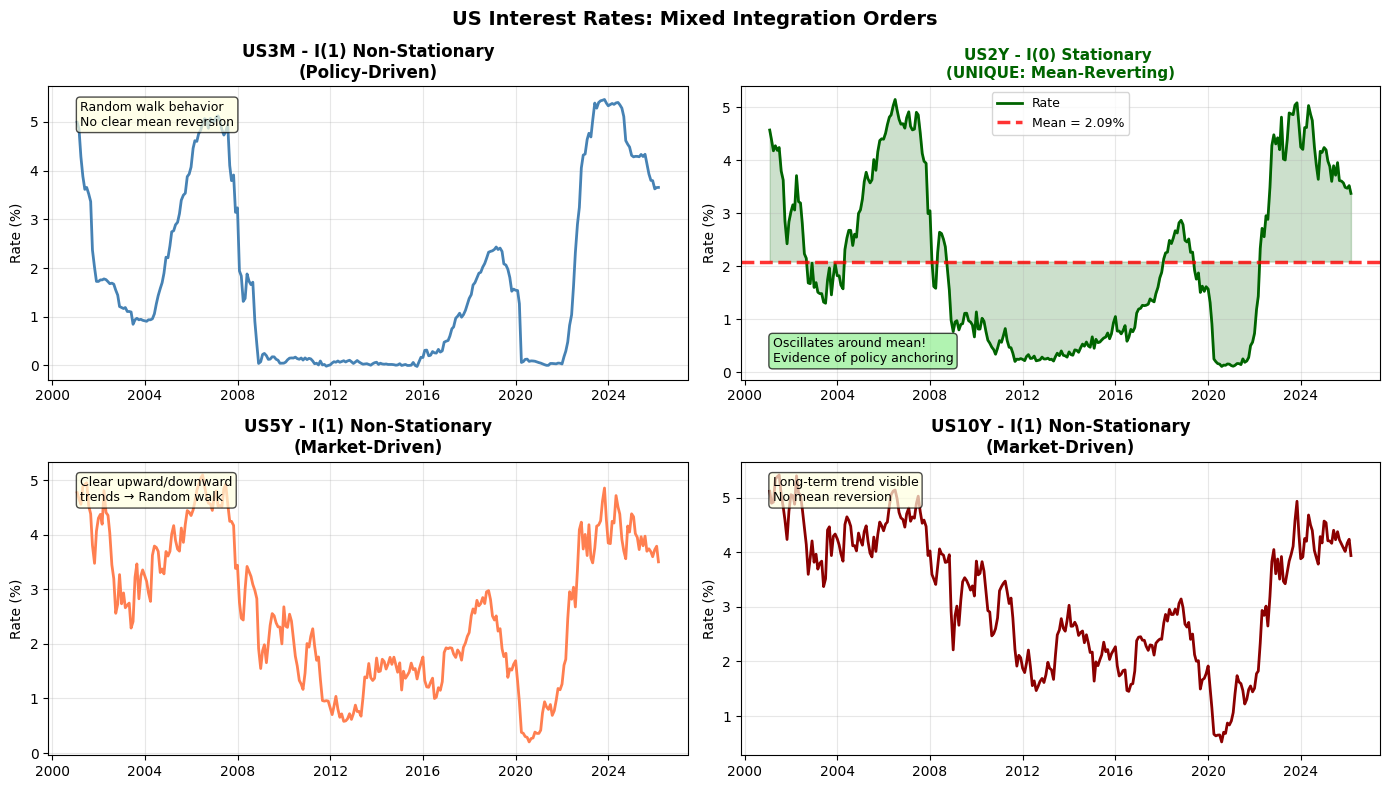

In [112]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('US Interest Rates: Mixed Integration Orders', fontsize=14, fontweight='bold')

# US3M - I(1)
ax = axes[0, 0]
ax.plot(interest_rates_df.index, interest_rates_df['US3M'], linewidth=2, color='steelblue')
ax.set_title('US3M - I(1) Non-Stationary\n(Policy-Driven)', fontweight='bold')
ax.set_ylabel('Rate (%)')
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, 'Random walk behavior\nNo clear mean reversion',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7), fontsize=9)

# US2Y - I(0) 
ax = axes[0, 1]
ax.plot(interest_rates_df.index, interest_rates_df['US2Y'], linewidth=2, color='darkgreen', label='Rate')
ax.axhline(y=interest_rates_df['US2Y'].mean(), color='red', linestyle='--', 
           linewidth=2.5, alpha=0.8, label=f"Mean = {interest_rates_df['US2Y'].mean():.2f}%")
ax.fill_between(interest_rates_df.index, interest_rates_df['US2Y'], 
                 interest_rates_df['US2Y'].mean(), alpha=0.2, color='darkgreen')
ax.set_title('US2Y - I(0) Stationary \n(UNIQUE: Mean-Reverting)', fontweight='bold', 
             color='darkgreen', fontsize=11)
ax.set_ylabel('Rate (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.05, 'Oscillates around mean!\nEvidence of policy anchoring',
        transform=ax.transAxes, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7), fontsize=9)

# US5Y - I(1)
ax = axes[1, 0]
ax.plot(interest_rates_df.index, interest_rates_df['US5Y'], linewidth=2, color='coral')
ax.set_title('US5Y - I(1) Non-Stationary\n(Market-Driven)', fontweight='bold')
ax.set_ylabel('Rate (%)')
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, 'Clear upward/downward\ntrends → Random walk',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7), fontsize=9)

# US10Y - I(1)
ax = axes[1, 1]
ax.plot(interest_rates_df.index, interest_rates_df['US10Y'], linewidth=2, color='darkred')
ax.set_title('US10Y - I(1) Non-Stationary\n(Market-Driven)', fontweight='bold')
ax.set_ylabel('Rate (%)')
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, 'Long-term trend visible\nNo mean reversion',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7), fontsize=9)

plt.tight_layout()
#plt.savefig('revised_individual_rates_by_type.png', dpi=100, bbox_inches='tight')
plt.show()

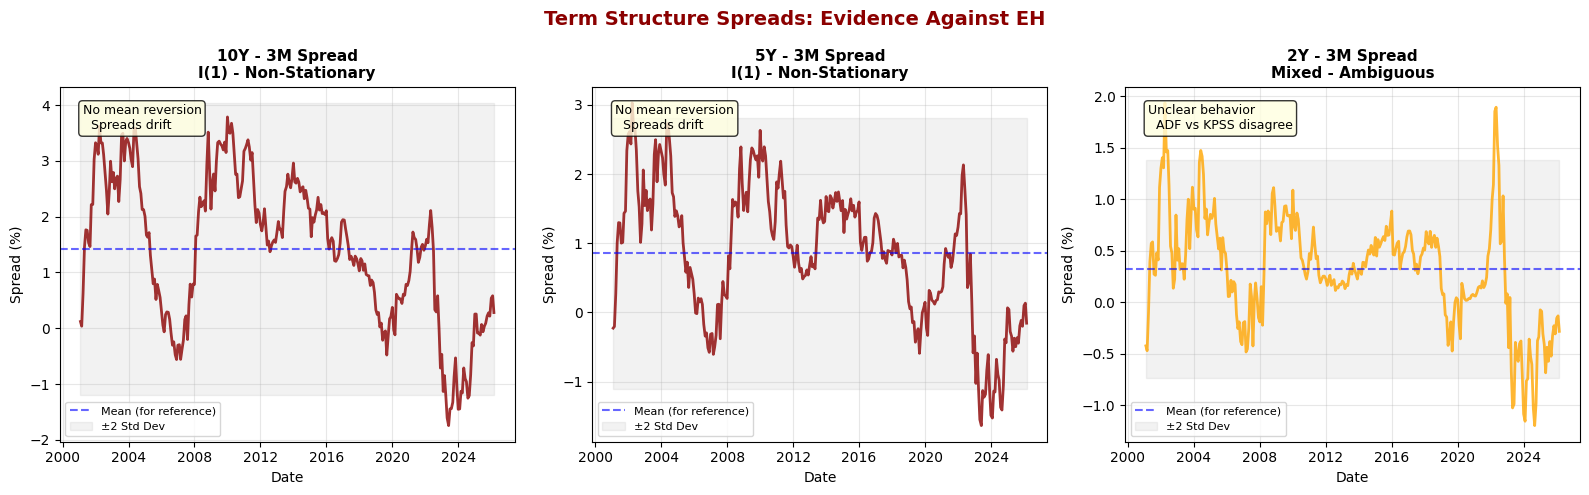

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Term Structure Spreads: Evidence Against EH', fontsize=14, fontweight='bold',
             color='darkred')

spreads_data = {
    '10Y_3M': interest_rates_df['US10Y'] - interest_rates_df['US3M'],
    '5Y_3M': interest_rates_df['US5Y'] - interest_rates_df['US3M'],
    '2Y_3M': interest_rates_df['US2Y'] - interest_rates_df['US3M'],
}

spread_colors = ['darkred', 'darkred', 'orange']
spread_titles = [
    '10Y - 3M Spread\nI(1) - Non-Stationary',
    '5Y - 3M Spread\nI(1) - Non-Stationary',
    '2Y - 3M Spread\nMixed - Ambiguous'
]

for idx, (spread_name, spread_data) in enumerate(spreads_data.items()):
    ax = axes[idx]
    
    ax.plot(spread_data.index, spread_data.values, linewidth=2, 
            color=spread_colors[idx], alpha=0.8)
    ax.axhline(y=spread_data.mean(), color='blue', linestyle='--', 
               linewidth=1.5, alpha=0.6, label='Mean (for reference)')
    
    # Add bands to show no mean reversion
    ax.fill_between(spread_data.index, 
                     spread_data.mean() - 2*spread_data.std(),
                     spread_data.mean() + 2*spread_data.std(),
                     alpha=0.1, color='gray', label='±2 Std Dev')
    
    ax.set_title(spread_titles[idx], fontweight='bold', fontsize=11)
    ax.set_xlabel('Date')
    ax.set_ylabel('Spread (%)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    
    # Add annotation
    if idx < 2:
        ax.text(0.05, 0.95, 'No mean reversion\n  Spreads drift',
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
                fontsize=9)
    else:
        ax.text(0.05, 0.95, 'Unclear behavior\n  ADF vs KPSS disagree',
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
                fontsize=9)

plt.tight_layout()
#plt.savefig('revised_spreads_non_stationary.png', dpi=100, bbox_inches='tight')
plt.show()